# AI Auto Repair Visual Assistant

This project is a multimodal AI tool for an emerging auto repair shop. It accepts a vehicle image and a text question and uses AI to provide visual observations, possible inspection areas, and recommended next steps. The tool supports preliminary inspection and does not replace a professional mechanic's diagnosis.

## Plan

1. Set up the Jupyter Notebook environment.
2. Accept a vehicle image and text question.
3. Analyze both inputs using multimodal AI.
4. Test the tool with realistic vehicle images.
5. Document problems, fixes, and final results.

In [47]:
%pip install huggingface_hub

Note: you may need to restart the kernel to use updated packages.


In [48]:
import os
from IPython.display import display, Image

In [49]:
from getpass import getpass
os.environ["HF_TOKEN"] = getpass("Enter Hugging Face token: ")

Enter Hugging Face token:  ········


In [50]:
from huggingface_hub import InferenceClient

client = InferenceClient(
    api_key=os.environ["HF_TOKEN"]
)

print("AI connection ready")

AI connection ready


In [54]:
model = "Qwen/Qwen2.5-VL-72B-Instruct:ovhcloud"
print("Vision model ready")

Vision model ready


In [55]:
def analyze_image(image_path, question):
    import base64

    with open(image_path, "rb") as f:
        image = base64.b64encode(f.read()).decode()

    response = client.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": question},
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/jpeg;base64,{image}"
                        }
                    }
                ]
            }
        ],
        max_tokens=300
    )

    return response.choices[0].message.content

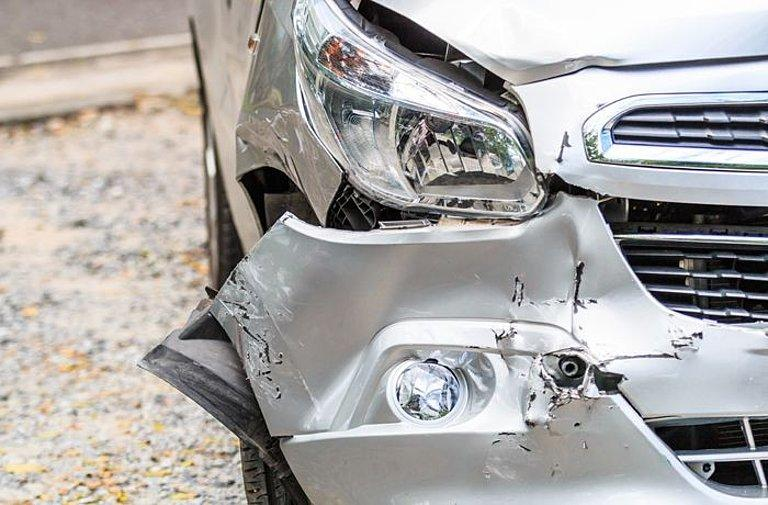

This image shows the front end of a vehicle that has sustained significant damage, likely from a collision. Here are some observations and areas that should be inspected:

### Observations:
1. **Bumper Damage**: The front bumper is severely damaged, with visible cracks and dents.
2. **Headlight Damage**: The headlight on the driver's side appears to be intact but may need inspection for functionality.
3. **Fender Damage**: The fender shows signs of impact, with creases and possible structural damage.
4. **Grille and Hood**: The grille and hood also show signs of impact, with the hood appearing slightly misaligned.

### Areas to Inspect:
1. **Structural Integrity**: Check the frame and chassis for any misalignment or damage that could affect the vehicle's safety and handling.
2. **Headlights and Lighting Systems**: Ensure that all lights (headlights, turn signals, etc.) are functioning properly.
3. **Airbag System**: Inspect the airbag system for deployment or damage, as it may need to 

In [56]:
image_path = "images/car1.jpg"
question = "What can you observe in this vehicle image and what should be inspected?"

result = analyze_image(image_path, question)

display(Image(filename=image_path))
print(result)

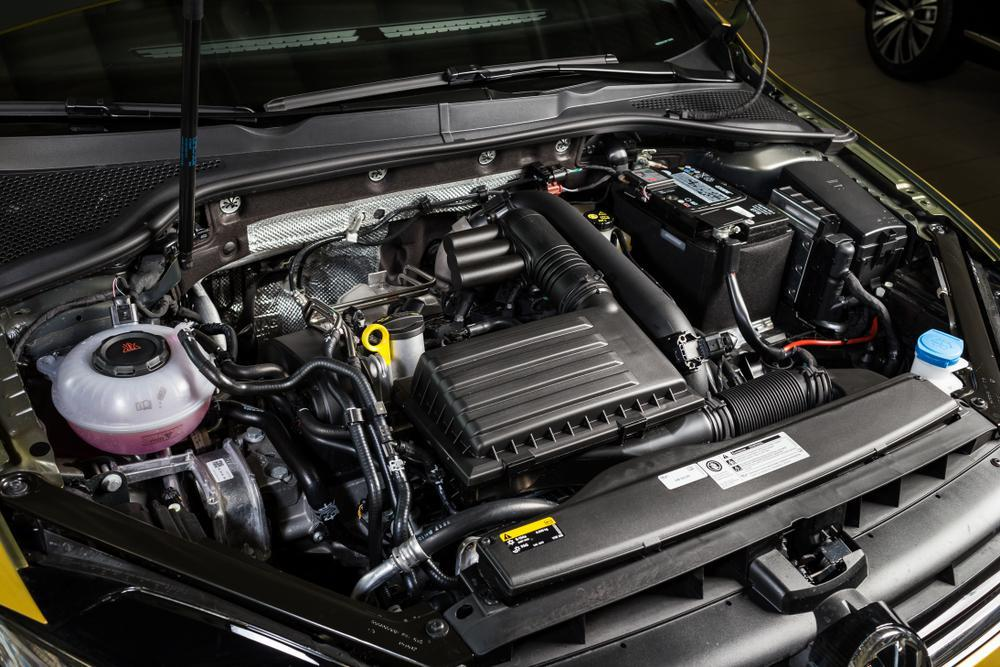

This image shows the engine compartment of a vehicle, with various components visible. Here's what can be observed and what should be inspected:

### Observations:
1. **Engine Cover**: The engine cover is visible, which typically conceals the engine block. It appears to be in good condition.
2. **Battery**: The battery is located on the right side of the engine bay. It looks clean and properly installed.
3. **Air Intake System**: The air intake system, including the air filter housing, is visible. It appears intact.
4. **Coolant Reservoir**: The coolant reservoir (pink cap) is on the left side. It seems to be at an appropriate level.
5. **Brake Fluid Reservoir**: The brake fluid reservoir (blue cap) is also visible. It appears to be filled to the correct level.
6. **Hoses and Wires**: Various hoses and wires are connected throughout the engine bay. They appear to be in place and not visibly damaged.
7. **Labels and Stickers**: There are labels and stickers on the engine bay, which may 

In [57]:
image_path = "images/car2.jpg"
question = "What can you observe in this vehicle image and what should be inspected?"

result = analyze_image(image_path, question)

display(Image(filename=image_path))
print(result)

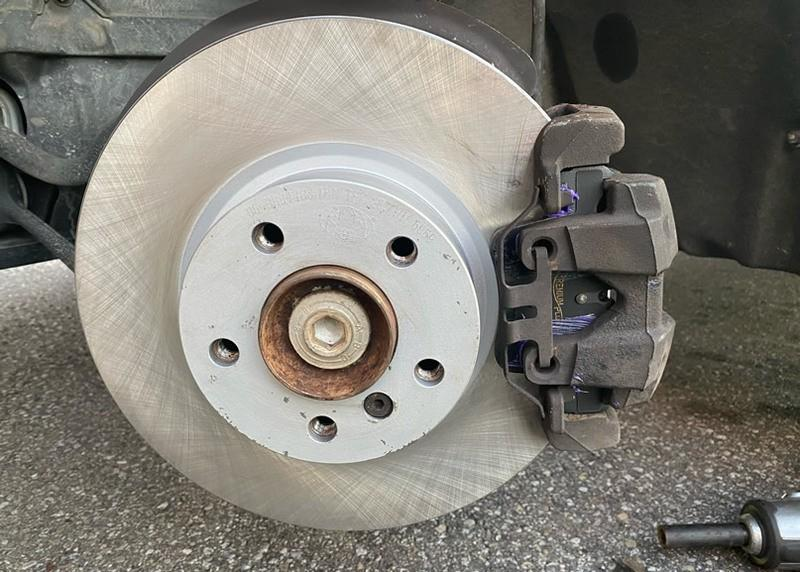

This image shows the brake assembly of a vehicle, specifically focusing on the brake rotor and caliper. Here are some observations and items that should be inspected:

### Observations:
1. **Brake Rotor:**
   - The rotor appears to have some wear, as indicated by the visible grooves or scratches on its surface.
   - There is some rust around the center hub area, which is common but should be monitored.

2. **Brake Caliper:**
   - The caliper looks intact but should be checked for any signs of leakage or damage.
   - The brake pads inside the caliper appear to be partially visible and may need inspection for wear.

3. **General Condition:**
   - The overall condition suggests that the brake system has been used and may require maintenance.

### Items to Inspect:
1. **Brake Rotor:**
   - Check for excessive wear, grooves, or warping. If the rotor is significantly worn or damaged, it may need to be resurfaced or replaced.
   - Inspect for any cracks or damage.

2. **Brake Caliper:**
   - 

In [58]:
image_path = "images/car3.jpg"
question = "What can you observe in this vehicle image and what should be inspected?"

result = analyze_image(image_path, question)

display(Image(filename=image_path))
print(result)

In [59]:
image_path = "images/missing.jpg"
question = "What can you observe in this vehicle image?"

try:
    result = analyze_image(image_path, question)
    print(result)
except Exception as e:
    print("Error handled:", e)

Error handled: [Errno 2] No such file or directory: 'images/missing.jpg'


In [60]:
image_path = "images/car1.jpg"
question = ""

try:
    result = analyze_image(image_path, question)
    print(result)
except Exception as e:
    print("Error handled:", e)

The image shows the front end of a car that has been involved in an accident. The damage is primarily concentrated on the bumper and headlight area. The bumper appears to be cracked and misaligned, with visible dents and scratches. The headlight is also damaged, with cracks and possibly some internal damage. The car's grille and other parts of the front end show signs of impact as well. The overall condition suggests a significant collision, likely at a moderate speed.


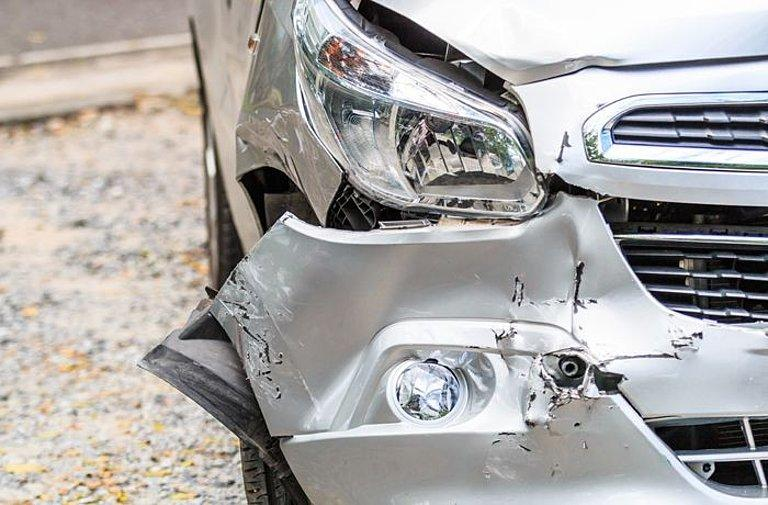

The image shows a damaged front bumper and headlight area of a vehicle, but without specific details about the make, model, year, location, and extent of internal damage, it's impossible to provide an exact repair cost. 

However, here are some general factors that could influence the cost:

1. **Make and Model**: Different vehicles have different costs for parts and labor.
2. **Extent of Damage**: The image shows visible damage to the bumper and possibly the headlight. There might also be unseen damage to other components like the radiator, grille, or even the frame.
3. **Labor Costs**: The cost of labor varies by region and the specific repair shop.
4. **Parts Availability**: Some parts may need to be ordered, which can add to the cost and time.

To get an accurate estimate, you should take the vehicle to a reputable auto body shop for a detailed inspection and quote. They will be able to assess all the damages and provide a precise cost for repairs.


In [61]:
image_path = "images/car1.jpg"
question = "Can you tell me the exact repair cost for this vehicle?"

result = analyze_image(image_path, question)

display(Image(filename=image_path))
print(result)